In [152]:
import pandas as pd
import os

Lectura de datos

In [153]:
data_abril = pd.read_csv('../data/raw/respuestas_abril.csv')
data_abril

,id,NPS,descripcion,p1,categoria,clasificacion,Unnamed: 6,Unnamed: 7,interesante
0,60882907,10,chirriztun16@gmail.com super genial util sencillo,101,Fácil de usar,Positiva,NaN,NaN,NaN
1,60198234,10,"muy útil, intuitiva y eficaz!",101,Fácil de usar,Positiva,NaN,NaN,NaN
2,60259661,10,está entendible y útil,101,Fácil de usar,Positiva,NaN,NaN,NaN
3,60484383,10,fácil de utilizar,101,Fácil de usar,Positiva,NaN,NaN,NaN
4,60789810,10,muy práctica y fácil,101,Fácil de usar,Positiva,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2757,60910658,10,no me deja ver sinpuedo acceder a una tarjeta ...,vacío,NaN,Negativa,NaN,NaN,NaN
2758,60911051,10,permitir hacer transferencia a cualquier hora ...,vacío,NaN,Neutral,NaN,NaN,NaN
2759,60911206,10,excelente app me funcionado de lo mejor,vacío,NaN,Positiva,NaN,NaN,NaN
2760,60911207,4,las compras deberían reflejarse de inmediato d...,vacío,NaN,Neutral,NaN,NaN,NaN


In [ ]:
# select columns of interest
columns_of_interest = ["descripcion","categoria","clasificacion"]
data_abril = data_abril[columns_of_interest]

#rename categoria a label
data_abril["label"]=data_abril["categoria"]

In [155]:
# grpupby clasificacion and count
data_abril.groupby('clasificacion').count()


,descripcion,categoria
clasificacion,,
Negativa,504,195
Neutral,540,150
Positiva,1718,1451


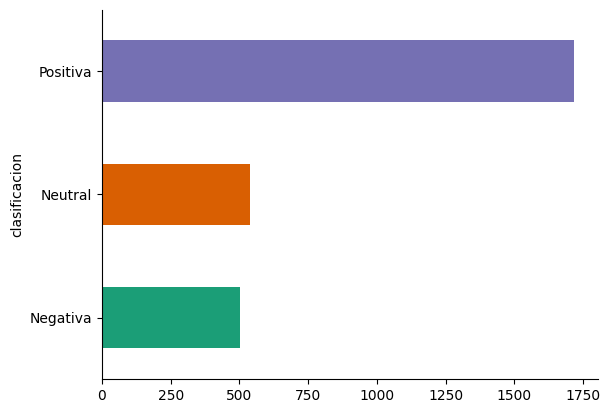

In [156]:
from matplotlib import pyplot as plt
import seaborn as sns
data_abril.groupby('clasificacion').size().plot(kind='barh', color=sns.color_palette("Dark2"))
plt.gca().spines[['top',"right"]].set_visible(False)


In [157]:
data_abril.dtypes

descripcion      str
categoria        str
clasificacion    str
dtype: object

In [158]:
# tamaño de muestra 
print(f"Tamaño del dataset de muestra es: {data_abril.shape[0]} registros")

Tamaño del dataset de muestra es: 2762 registros


In [159]:
# @ instalacion de librerias
#!pip install transformers
!pip install transformers torch
!pip install pytorch_pretrained_bert

In [160]:
# torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torch.nn.functional as F
import torch.optim as optim

from collections import Counter
import argparse
import functools
from torch.utils.data import DataLoader

import json
import numpy as np
from tqdm import tqdm
import shutil

In [161]:
from transformers import BertTokenizer, BertModel

# BETO: BERT entrenado en español (Wikipedia + corpus español)
#tokenizer = BertTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
#model = BertModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

In [162]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data_abril, test_size=0.1, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.11, random_state=42)

In [163]:
print(f"Tamaño del dataset de entrenamiento es: {train_data.shape[0]} registros")
print(f"Tamaño del dataset de prueba es: {test_data.shape[0]} registros")
print(f"Tamaño del dataset de validación es: {val_data.shape[0]} registros")

Tamaño del dataset de entrenamiento es: 2211 registros
Tamaño del dataset de prueba es: 277 registros
Tamaño del dataset de validación es: 274 registros


In [164]:
# Guardar datasets en csv
train_data.to_csv('../data/processed/train_data.csv', index=False)
test_data.to_csv('../data/processed/test_data.csv', index=False)
val_data.to_csv('../data/processed/val_data.csv', index=False)

In [165]:
class ReviewDataset(Dataset):
    """
    data_path: ruta del archivo .csv que contiene descripcion y categoria
    Args: hiperparametros
    """
    def __init__(self, data_path, args):
        self.data = pd.read_csv(data_path)
        self.tokenizer = BertTokenizer.from_pretrained(
            args.bert_model,
            do_lower_case=True
        ) # funcion que preprocesa el texto y divide en tokens
        self.args = args
        self.n_classes = len(args.labels)
        self.max_seq_length = args.max_seq_length # 512
    
    def __len__(self):
        return len(self.data)
    
    def load_text(self, index, key=""):
        inputs = self.tokenizer(self.data.loc[index, key], return_tensors='pt', padding='max_length', truncation=True)
        sentence =inputs.input_ids[0]
        segment = inputs.token_type_ids[0]
        attmask = inputs.attention_mask[0]
        return sentence, segment, attmask
    
    def __getitem__(self, index):
        sentence, segment, attmask = None, None, None

        # cargar texto y procesar con tokenizer
        sentence, segment, attmask = self.load_text(index, key="descripcion")

        label = torch.zeros(self.n_classes)
        
        tgt = self.data.loc[index]["categoria"]
        label[self.args.labels.index(tgt)] = 1
        return sentence, segment, attmask, label


In [166]:
def get_labels_and_frequencies(path):
    """
     Lee el archivo csv en la ruta dada, extrae las etiquetas de la columna 'categoria' y calcula la frecuencia de cada etiqueta.
     Devuelve una lista de etiquetas únicas y un diccionario con la frecuencia de cada etiqueta."""
    label_freqs = Counter()
    data_labels = list(pd.read_csv(path)['categoria'])
    label_freqs.update(data_labels)
    return list(label_freqs.keys()), label_freqs

In [167]:
def collate_fn(batch,args):
    text_tensor, segment_tensor, attmask_tensor, label_tensor = None, None, None, None

    text_tensor =    torch.stack([row[0] for row in batch])
    segment_tensor = torch.stack([row[1] for row in batch])
    attmask_tensor = torch.stack([row[2] for row in batch])
    tgt_tensor =     torch.stack([row[3] for row in batch])

    return text_tensor, segment_tensor, attmask_tensor, tgt_tensor

In [168]:
def get_data_loaders(args):
    args.labels, args.label_freqs = get_labels_and_frequencies(
        os.path.join(args.data_path, "train_data.csv")
        )
    
    args.n_classes = len(args.labels)

    train = ReviewDataset(os.path.join(args.data_path, "train_data.csv"), args)
    
    args.train_data_len = len(train)

    dev = ReviewDataset(os.path.join(args.data_path, "val_data.csv"), args)

    test_set = ReviewDataset(os.path.join(args.data_path, "test_data.csv"), args)

    collate = functools.partial(collate_fn, args=args)

    train_loader = DataLoader(
        train, 
        batch_size=args.batch_size, 
        shuffle=True, 
        num_workers=args.num_workers,
        collate_fn=collate)
    
    val_loader = DataLoader(
        dev, 
        batch_size=args.batch_size, 
        shuffle=False, 
        num_workers=args.num_workers,
        collate_fn=collate) 
    
    test_loader = DataLoader(
        test_set, 
        batch_size=args.batch_size, 
        shuffle=False, 
        num_workers=args.num_workers,
        collate_fn=collate)
    
    return train_loader, val_loader, test_loader

Configuracion del entrenamiento 

In [169]:
import random
# fijar semilla para reproduccion
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [170]:
def model_forward(i_epoch, model, args, criterion, batch):
    txt, segment, attmask, tgt = batch
    txt, attmask, segment = txt.to(args.device), attmask.to(args.device), segment.to(args.device)
    out = model(txt, attmask, segment) # la log probabilidad de cada clase para cada ejemplo del batch

    tgt = tgt.to(args.device)
    final_loss = criterion(out, tgt)
    return final_loss, out, tgt


In [171]:
# para evaluar el modelo
from sklearn.metrics import f1_score, accuracy_score, average_precision_score
from sklearn.metrics import precision_score, recall_score, classification_report
# average_recall_score
#from 

In [172]:
def model_eval(i_epoch, data, model, args, criterion):
    # no queremos que se propague el gradiente durante la evaluación, por eso usamos torch.no_grad()
    with torch.no_grad():
        losses, preds, tgts = [], [], []
        probs = []
        for batch in data:
            loss, out, tgt = model_forward(i_epoch, model, args, criterion, batch)
            losses.append(loss.item())
            prob = torch.nn.functional.softmax(out, dim=1).cpu().detach().numpy()
            index_max = np.argmax(prob, axis=1)
            pred = np.zeros(prob.shape)
            for i in range(len(index_max)):
                pred[i][index_max[i]] = 1
            preds.append(pred)
            probs.append(prob)
            tgt = tgt.cpu().detach().numpy()
            tgts.append(tgt)

    tgts = np.vstack(tgts)
    preds = np.vstack(preds)
    probs = np.vstack(probs)
    report = classification_report(tgts, preds, output_dict=True)
    #print(report)
    metrics = {"loss": np.mean(losses), 
              "weighted avg precision": report["weighted avg"],
               }
    return metrics


In [173]:
# guarda en cada epoca el estado del modelo actual
def save_checkpoint(state, is_best, checkpoint_path, filename="checkpoint.pt"):
    filename = os.path.join(checkpoint_path, filename)
    torch.save(state, filename)
    if is_best:
        shutil.copyfile(filename, os.path.join(checkpoint_path, "best_model.pt"))

In [174]:
def train(args, model):
    args.savedir = os.path.join(args.savedir, args.name)
    os.makedirs(args.savedir, exist_ok=True)

    model.to(args.device)

    torch.save(args, os.path.join(args.savedir, "args.pt"))
    start_epoch, global_step, n_no_improve, best_metric = 0, 0, 0, -np.inf

    # cargar el estado del modelo si ya existia previamente
    if os.path.exists(os.path.join(args.savedir, "checkpoint.pt")):
        checkpoint = torch.load(os.path.join(args.savedir, "checkpoint.pt"))

        start_epoch = checkpoint["epoch"] + 1
        global_step = checkpoint["global_step"]
        n_no_
        e = checkpoint["n_no_improve"]
        best_metric = checkpoint["best_metric"]
        model.load_state_dict(checkpoint["state_dict"])
        # configurar el optimizador y la función de pérdida
        optimizer.load_state_dict(checkpoint["optimizer"])
        scheduler.load_state_dict(checkpoint["scheduler"])
        print(f"Modelo cargado desde checkpoint, empezando en epoch {start_epoch} con global step {global_step} y mejor métrica {best_metric}")
    
    len_train = len(train_loader)
    # cuando termina la epoca la ponemos en modo evaluacion
    for i_epoch in range(start_epoch, args.max_epochs):
        train_losses = []
        model.train()

        for batch in tqdm(train_loader, total=len_train):
            los, _, _ = model_forward(i_epoch, model, args, criterion, batch)
            if args.gradient_accumulation_steps > 1:
                los = los / args.gradient_accumulation_steps
            train_losses.append(los.item())
            # propagar el gradiente
            los.backward()
            global_step += 1

            if global_step % args.gradient_accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()
        
        model.eval() # desactiva el dropout y otras capas que solo se usan durante el entrenamiento
        # metricas de evaluacion en el set de validacion para monitorear el entrenamiento y ver si el modelo esta mejorando o si se esta sobreajustando
        metrics = model_eval(i_epoch, val_loader, model, args, criterion)
        print(f"Epoch {i_epoch} - Train Loss: {np.mean(train_losses):.4f}")
        print("Val: ", metrics)


        tunning_metric = (
            # como va el f1 score
            metrics["weighted avg"]["f1-score"]
        )
        # como tiene que reduc
        scheduler.step(tunning_metric)

        is_improvement = tunning_metric > best_metric
        if is_improvement:
            best_metric = tunning_metric
            n_no_improve = 0
        else:
            n_no_improve += 1

        # guardar el estado del modelo actual
        save_checkpoint({
            "epoch": i_epoch,
            "n_no_improve": n_no_improve,
            "best_metric": best_metric,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict()
        }, is_improvement, args.savedir)
        # early stopping
        if n_no_improve >= args.patience: # si no mejora durante un numero de epocas consecutivas, se detiene el entrenamiento para evitar sobreajuste
            print(f"No se ha mejorado durante {n_no_improve} epocas consecutivas. Deteniendo entrenamiento.")
            break

        load_checkpoint(model, os.path.join(args.savedir, "best_model.pt"))
        model.eval()
        test_metrics = model_eval(
            np.inf, test_loader, model, args, criterion
        )
        print(f"Tests:", test_metrics)


In [175]:
def load_checkpoint(model, path):
    best_checkpoint = torch.load(path)
    model.load_state_dict(best_checkpoint["state_dict"])

BERT - BERTO

cLASIFICADOR

In [176]:
class BertClassfier(nn.Module):
    def __init__(self, args):
        super(BertClassfier, self).__init__()
        self.bert = BertModel.from_pretrained(args.bert_model) # Encoder de texto preentrenado
        self.dropout = nn.Dropout(args.dropout)
        self.classifier = nn.Linear(args.hidden_size, args.n_classes) # cabezal de clasificacion que toma la representacion del [CLS] token y devuelve la log probabilidad de cada clase

    def forward(self, txt, mask, segment):
        """como evaluar
        """
        _, x = self.bert(
            input_ids=txt, 
            attention_mask=mask, 
            token_type_ids=segment,
            return_dict=False
        )

        x = self.dropout(x) # capa de droput
        return self.classifier(x)

Entrenamiento

In [177]:
import os
# Verificar disponibilidad de CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

set_seed(1)
args = argparse.Namespace(
    bert_model="dccuchile/bert-base-spanish-wwm-uncased", # modelo preentrenado de BERT en español BASE
    model="bert",
    batch_size=8,
    max_seq_length=512,
    num_workers=0, # 2 en colab
    dropout=0.1,
    hidden_size=768, # ESPACIO SEMANTICO
    gradient_accumulation_steps=16,
    max_epochs=10,
    lr_patience=2, # 2 epocas cuando no mejore se detiene el entrenamiento
    lr=1e-4, # tasa de aprendizaje
    lr_factor=0.5,
    warmup=0.1,
    data_path="../data/processed", # ruta a los datos
    savedir="../models", # ruta a los directorios de guardado
    task="", # tarea a resolver
    name="bert_base_spanish_wwm_uncased", # nombre del modelo
    device=device,
)

Usando dispositivo: cpu


In [178]:
train_loader, val_loader, test_loader = get_data_loaders(args)

In [179]:
bert_base = BertClassfier(args)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 58609.58it/s]
BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newl

In [180]:
# Estructura del modelo
bert_base.bert

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(31002, 768, padding_idx=1)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [181]:
# Criterion
freqs = [args.label_freqs[label] for label in args.labels]
# pondera las clases en funcion del numero de ejemplos de cada clase en el set de entrenamiento, para que el modelo no se sesgue hacia las clases mayoritarias
label_weights = (torch.FloatTensor(freqs)/args.train_data_len) ** -1
label_weights = label_weights.to(args.device)
criterion = nn.BCEWithLogitsLoss(weight=label_weights)
bert_base.to(args.device)
#optimizador
optimizer = optim.AdamW(bert_base.parameters(), lr=args.lr)
# scheduler para reducir la tasa de aprendizaje si no mejora la métrica de evaluación
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=args.lr_patience, factor=args.lr_factor)


In [182]:
train(args, bert_base)

100%|██████████| 277/277 [45:16<00:00,  9.81s/it] 
/Users/danielmiranda/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielmiranda/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielmiranda/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` p

100%|██████████| 277/277 [45:16<00:00,  9.81s/it] 
/Users/danielmiranda/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielmiranda/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielmiranda/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` p

KeyError: 'accuracy'

Evaluar predicciones unitarias

In [ ]:
def model_predict(model, text, args):
    with torch.no_grad():
        tokenizer = BertTokenizer.from_pretrained(args.bert_model, do_lower_case=True)
        inputs = tokenizer(text, return_tensors="pt", padding="max_length", truncation=True)
        txt = inputs.input_ids
        segment = inputs.token_type_ids
        attmask = inputs.attention_mask
        txt, attmask, segment = txt.to(args.device), attmask.to(args.device), segment.to(args.device)
        
        out = bert_base(txt, attmask, segment)
        prob = torch.nn.functional.softmax(out[0], dim=0)
        index_max = prob.argmax(axis=0)
        pred = args.labels[index_max]

        return pred, prob


In [ ]:
text = "la app es muy facil de usar y me facilita mucho hacer mis pagos y transferencias. asi como consultar mis estados de cuenta. siempre la recomiendo. gracias por el excelente servicio"
model_predict(bert_base, text, args)

In [ ]:
text = "gshhwy"
model_predict(bert_base, text, args)

In [ ]:
text = "transferir desde un apartado."
model_predict(bert_base, text, args)

In [ ]:
# retrival es el match entre la valoracion y lo que esta en la base de conocimiento, y el generative es la respuesta que se le da al cliente, que puede ser una respuesta predefinida o una respuesta generada por el modelo a partir de la base de conocimiento.

Referencias

Speech and Language Processing Dan Jurafsky ans James H martin - stanford
Attention is all you need